# Customer Lifetime Value (CLTV) Analysis

## Objective
To calculate customer lifetime value and identify high-value customers using historical transaction data.

## Dataset Loading

In [1]:
import pandas as pd
df = pd.read_csv("../data/cleaned/cleaned_retail_day3.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Revenue Analysis

In [2]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]

In [3]:
customer_revenue = ( df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False))

customer_revenue.head()

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
Name: Sales, dtype: float64

## Average Order Value (AOV)

In [4]:
aov = (df.groupby("InvoiceNo")["Sales"].sum().mean())

print("Average Order Value:", aov)

Average Order Value: 479.56016047917126


## Purchase Frequency Analysis

In [5]:
purchase_frequency = (df.groupby("CustomerID")["InvoiceNo"].nunique().mean())

print("Purchase Frequency:", purchase_frequency)

Purchase Frequency: 4.272014753342554


## Customer Lifetime Value Calculation

In [6]:
cltv = aov * purchase_frequency

print("Customer Lifetime Value:", cltv)

Customer Lifetime Value: 2048.6880806823424


## Customer Segment Distribution

In [7]:
customer_revenue.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Sales, dtype: float64

## Revenue-Based Customer Segmentation

In [8]:
q1 = customer_revenue.quantile(0.25)
q3 = customer_revenue.quantile(0.75)

def segment_customer(x):
    if x >= q3:
        return "High Value"
    elif x >= q1:
        return "Medium Value"
    else:
        return "Low Value"

customer_segments = customer_revenue.reset_index()
customer_segments.columns = ["CustomerID","Revenue"]

customer_segments["Segment"] = customer_segments["Revenue"].apply(segment_customer)

customer_segments["Segment"].value_counts()

Segment
Medium Value    2168
High Value      1085
Low Value       1085
Name: count, dtype: int64

### Customer Segment Distribution

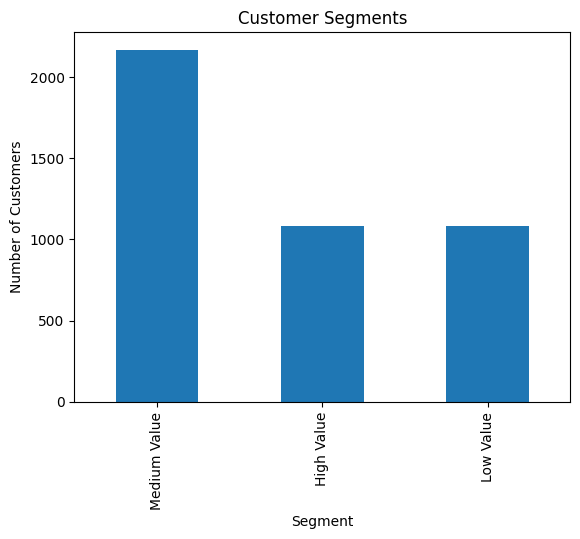

In [9]:
import matplotlib.pyplot as plt
customer_segments["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

## Customer Segmentation Insights

1. Customers have been grouped into High Value, Medium Value, and Low Value segments.

2. High Value customers contribute a disproportionately large share of revenue.

3. Retaining High Value customers should be a priority.

4. Medium Value customers present opportunities for growth through targeted marketing.

5. Low Value customers may require engagement strategies to increase purchase frequency.

## Top Customers by Revenue

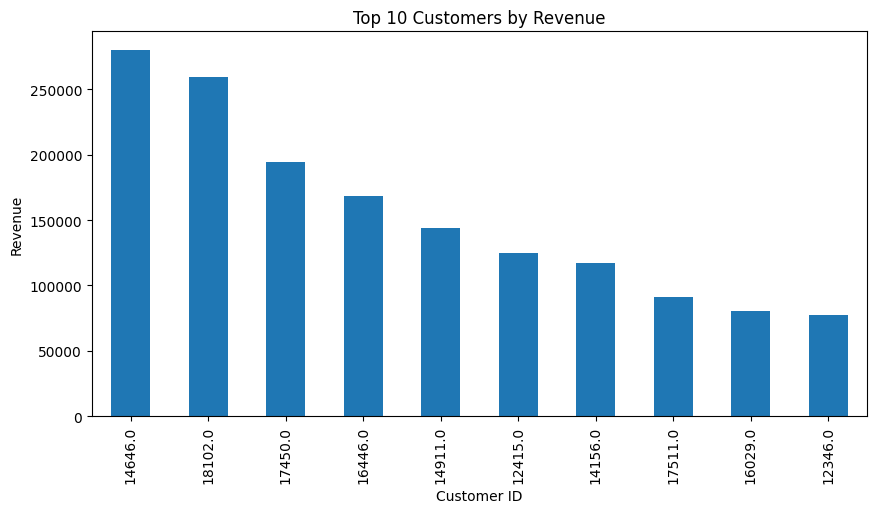

In [10]:
top_customers = customer_revenue.head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

## Customer Revenue Distribution

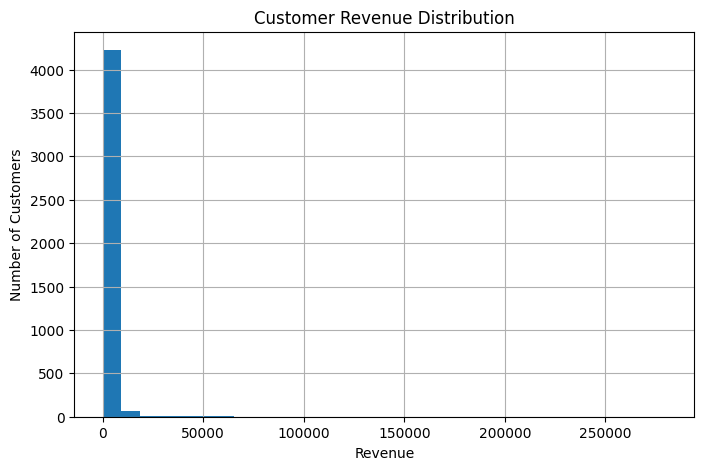

In [11]:
plt.figure(figsize=(8,5))

customer_revenue.hist(bins=30)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.show()

## Customer Purchase Frequency Distribution

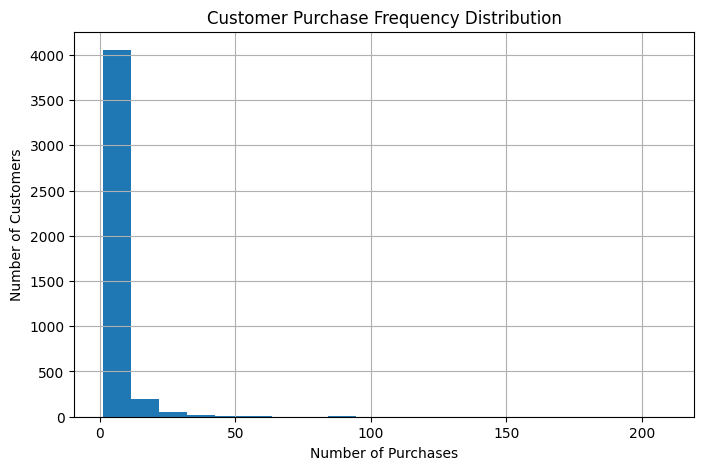

In [12]:
customer_frequency = (df.groupby("CustomerID")["InvoiceNo"].nunique())

plt.figure(figsize=(8,5))

customer_frequency.hist(bins=20)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

## CLTV Analysis Insights

1. A small number of customers contribute a significant portion of total revenue.

2. Most customers generate relatively low revenue compared to top-performing customers.

3. Customer purchase frequency varies significantly across the customer base.

4. High-frequency customers contribute more to overall customer lifetime value.

5. Retaining high-value customers can have a substantial impact on business revenue.

## Business Recommendations

1. Focus on retaining high-value customers through loyalty programs.

2. Create personalized marketing campaigns for repeat customers.

3. Monitor customer lifetime value regularly to identify valuable customer segments.

4. Encourage repeat purchases through targeted promotions and discounts.

5. Develop customer engagement strategies to increase purchase frequency.

## Conclusion

The CLTV analysis shows that a small group of customers contributes a significant share of total revenue. Customer purchase frequency and revenue contribution vary considerably across the customer base. By focusing on customer retention and increasing purchase frequency, businesses can improve customer lifetime value and long-term profitability.



# Customer-Level RFM Analysis

Instead of using overall averages, we calculate customer-level
Recency, Frequency and Monetary (RFM).

This forms the foundation for customer segmentation and
segment-wise CLTV analysis.

## Snapshot Date

A reference date is required to calculate customer recency. The snapshot date is defined as one day after the latest transaction in the dataset. This ensures that every customer's most recent purchase can be measured consistently in terms of the number of days since their last transaction.


In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [14]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [15]:
rfm = (
df.groupby("CustomerID")
      .agg({
          "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
          "InvoiceNo": "nunique",
          "Sales": "sum",
          "Country": "first" })
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "Country"
]

rfm.head()

,Recency,Frequency,Monetary,Country
CustomerID,,,,
12346.0,326,1,77183.60,United Kingdom
12347.0,2,7,4310.00,Iceland
12348.0,75,4,1797.24,Finland
12349.0,19,1,1757.55,Italy
12350.0,310,1,334.40,Norway


In [16]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


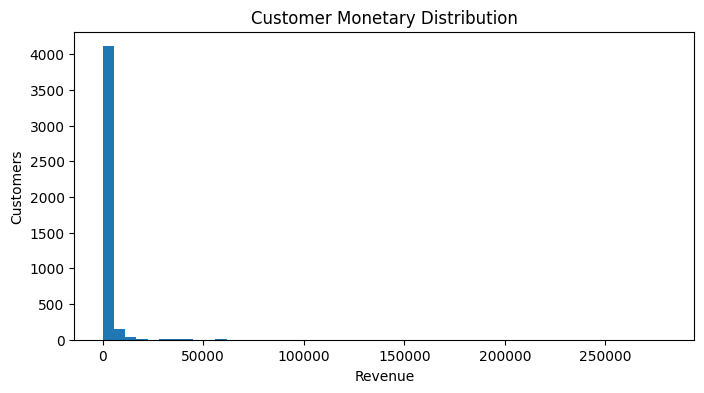

In [17]:
plt.figure(figsize=(8,4))
plt.hist(rfm["Monetary"], bins=50)

plt.title("Customer Monetary Distribution")
plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

In [18]:
rfm.sort_values(by="Monetary",ascending=False).head(10)

,Recency,Frequency,Monetary,Country
CustomerID,,,,
14646.0,2,73,280206.02,Netherlands
18102.0,1,60,259657.30,United Kingdom
17450.0,8,46,194390.79,United Kingdom
16446.0,1,2,168472.50,United Kingdom
14911.0,1,201,143711.17,EIRE
12415.0,24,21,124914.53,Australia
14156.0,10,55,117210.08,EIRE
17511.0,3,31,91062.38,United Kingdom
16029.0,39,63,80850.84,United Kingdom


In [19]:
rfm[["Recency","Frequency","Monetary"]].corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.260578,-0.121831
Frequency,-0.260578,1.000000,0.552780
Monetary,-0.121831,0.552780,1.000000


## Key Insights

* Customer purchasing behaviour varies considerably across the customer base.
* Revenue is concentrated among a relatively small group of high-value customers.
* Purchase frequency differs significantly between customers, indicating varying levels of engagement.
* The RFM table establishes a customer-level foundation for advanced analyses such as segment-wise CLTV, customer segmentation, churn analysis, and retention strategies.


# Segment-wise Historical CLTV Analysis

## Country-wise Average Order Value
Calculate the average order value for customers in each country.

In [20]:
country_aov = (
    df.groupby("Country")["Sales"].sum()
    / df.groupby("Country")["InvoiceNo"].nunique()
).sort_values(ascending=False)

country_aov.head(10)

Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2429.014211
Japan          1969.282632
Lebanon        1693.880000
Israel         1443.168000
Brazil         1143.600000
Switzerland    1106.744118
Sweden         1065.773056
Denmark        1053.074444
dtype: float64

## Country-wise Purchase Frequency
Measure the average purchase frequency of customers across different countries.

In [21]:
country_purchase_frequency = (
    df.groupby("Country")["InvoiceNo"].nunique()
    / df.groupby("Country")["CustomerID"].nunique()
).sort_values(ascending=False)

country_purchase_frequency.head(10)

Country
EIRE                  86.666667
Netherlands           10.444444
Singapore              7.000000
Iceland                7.000000
Australia              6.333333
Germany                4.861702
Sweden                 4.500000
France                 4.471264
United Kingdom         4.246429
European Community     4.000000
dtype: float64

## Country-wise Historical CLTV
Estimate historical customer lifetime value for each country using AOV and purchase frequency.

In [22]:
country_cltv = pd.DataFrame({
    "AverageOrderValue": country_aov,
    "PurchaseFrequency": country_purchase_frequency
})

country_cltv["HistoricalCLTV"] = (
    country_cltv["AverageOrderValue"]
    * country_cltv["PurchaseFrequency"]
)

country_cltv.sort_values(
    by="HistoricalCLTV",
    ascending=False
).head(10)

,AverageOrderValue,PurchaseFrequency,HistoricalCLTV
Country,,,
EIRE,1020.240231,86.666667,88420.820000
Netherlands,3036.663191,10.444444,31716.260000
Singapore,3039.898571,7.000000,21279.290000
Australia,2429.014211,6.333333,15383.756667
Sweden,1065.773056,4.500000,4795.978750
Japan,1969.282632,2.375000,4677.046250
Iceland,615.714286,7.000000,4310.000000
Norway,1004.595556,3.600000,3616.544000
Switzerland,1106.744118,2.428571,2687.807143


## Top Countries by Historical CLTV
Visualize the countries with the highest estimated customer lifetime value.

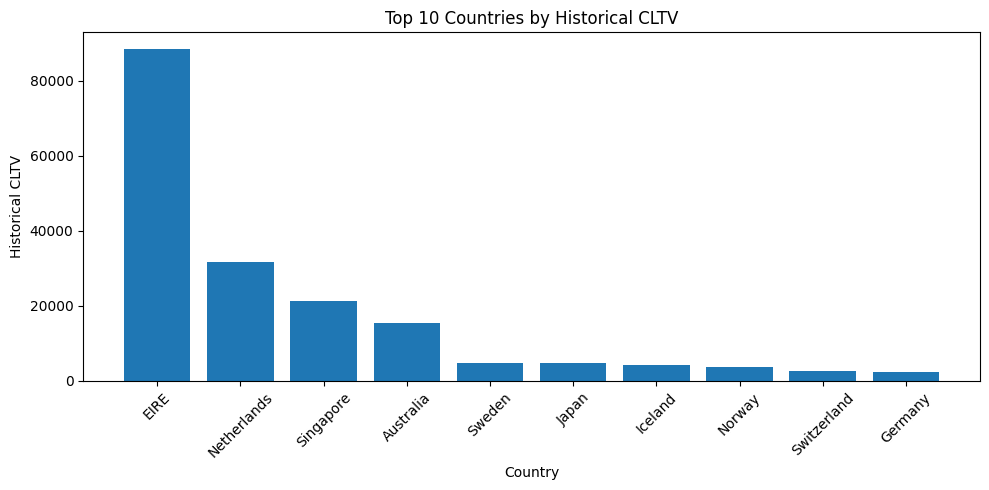

In [23]:
top10 = (
    country_cltv
    .sort_values("HistoricalCLTV", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(top10.index, top10["HistoricalCLTV"])

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Historical CLTV")

plt.xlabel("Country")

plt.ylabel("Historical CLTV")

plt.tight_layout()

plt.show()

## Key Insight
Compare historical CLTV across countries to identify high-value customer markets.

# Cohort-wise Historical CLTV Analysis

## Customer Cohort Creation
Assign each customer to their first purchase month for cohort-based CLTV analysis.

In [24]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

df["CohortMonth"] = (
    df.groupby("CustomerID")["InvoiceDate"]
      .transform("min")
      .dt.to_period("M")
)

In [25]:
df[["CustomerID", "InvoiceMonth", "CohortMonth"]].head()

,CustomerID,InvoiceMonth,CohortMonth
0,17850.0,2010-12,2010-12
1,17850.0,2010-12,2010-12
2,17850.0,2010-12,2010-12
3,17850.0,2010-12,2010-12
4,17850.0,2010-12,2010-12


## Cohort-wise Average Order Value

In [26]:
cohort_aov = (
    df.groupby("CohortMonth")["Sales"].sum()
    /
    df.groupby("CohortMonth")["InvoiceNo"].nunique()
)

cohort_aov

CohortMonth
2010-12    541.237019
2011-01    521.577790
2011-02    379.564292
2011-03    398.304631
2011-04    352.513973
2011-05    555.164139
2011-06    412.254811
2011-07    325.176224
2011-08    546.830698
2011-09    390.981044
2011-10    371.190576
2011-11    342.493554
2011-12    628.033953
Freq: M, dtype: float64

## Cohort-wise Purchase Frequency

In [27]:
cohort_purchase_frequency = (
    df.groupby("CohortMonth")["InvoiceNo"].nunique()
    /
    df.groupby("CohortMonth")["CustomerID"].nunique()
)

cohort_purchase_frequency

CohortMonth
2010-12    9.398870
2011-01    5.163070
2011-02    4.107895
2011-03    3.564159
2011-04    3.080000
2011-05    2.883803
2011-06    2.731405
2011-07    2.351064
2011-08    2.118343
2011-09    1.989967
2011-10    1.698324
2011-11    1.359133
2011-12    1.048780
Freq: M, dtype: float64

## Cohort-wise Historical CLTV


In [28]:
cohort_cltv = pd.DataFrame({
    "AverageOrderValue": cohort_aov,
    "PurchaseFrequency": cohort_purchase_frequency
})

cohort_cltv["HistoricalCLTV"] = (
    cohort_cltv["AverageOrderValue"]
    * cohort_cltv["PurchaseFrequency"]
)

cohort_cltv.sort_values(
    "HistoricalCLTV",
    ascending=False
)

,AverageOrderValue,PurchaseFrequency,HistoricalCLTV
CohortMonth,,,
2010-12,541.237019,9.398870,5087.016407
2011-01,521.577790,5.163070,2692.942400
2011-05,555.164139,2.883803,1600.983908
2011-02,379.564292,4.107895,1559.210158
2011-03,398.304631,3.564159,1419.621150
2011-08,546.830698,2.118343,1158.375089
2011-06,412.254811,2.731405,1126.034835
2011-04,352.513973,3.080000,1085.743037
2011-09,390.981044,1.989967,778.039201


## Historical CLTV by Cohort

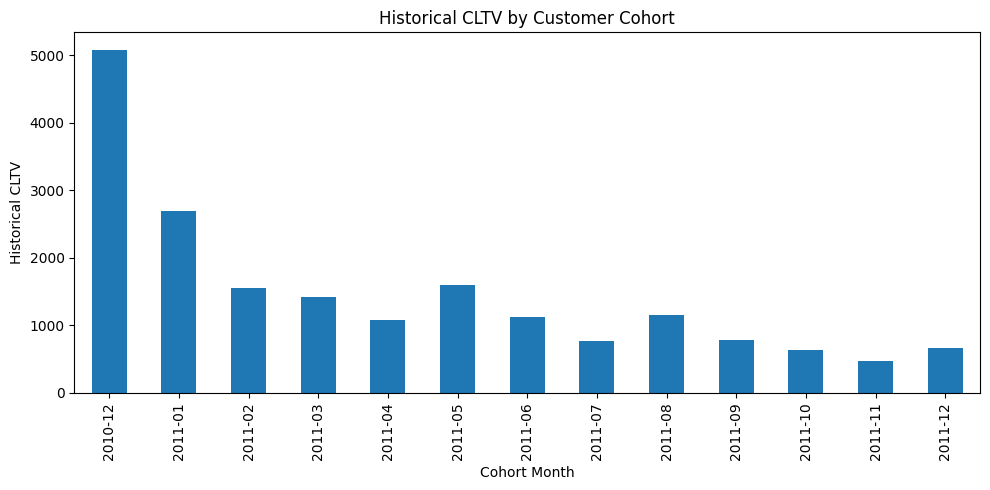

In [29]:
plt.figure(figsize=(10,5))

cohort_cltv["HistoricalCLTV"].plot(kind="bar")

plt.title("Historical CLTV by Customer Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Historical CLTV")

plt.tight_layout()
plt.show()

## Key Insight
Compare customer lifetime value across different acquisition cohorts.

# Global vs Segment-wise CLTV Comparison

## CLTV Comparison Table
Compare overall CLTV with country-wise and cohort-wise historical CLTV.

In [30]:
comparison = pd.DataFrame({
    "Metric": [
        "Global Historical CLTV",
        "Average Country CLTV",
        "Average Cohort CLTV"
    ],
    "Value": [
        cltv,
        country_cltv["HistoricalCLTV"].mean(),
        cohort_cltv["HistoricalCLTV"].mean()
    ]
})

comparison

,Metric,Value
0,Global Historical CLTV,2048.688081
1,Average Country CLTV,5859.817634
2,Average Cohort CLTV,1463.618631


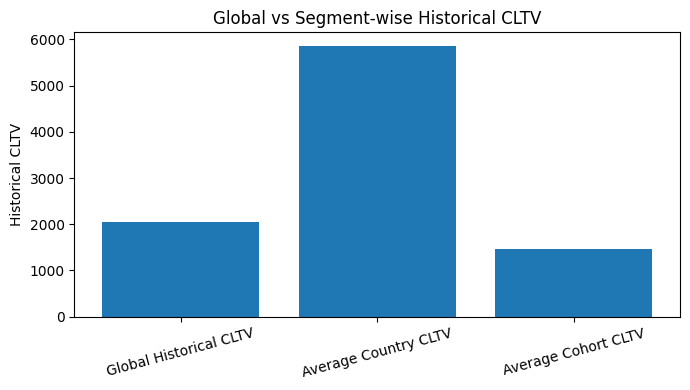

In [31]:
plt.figure(figsize=(7,4))

plt.bar(
    comparison["Metric"],
    comparison["Value"]
)

plt.title("Global vs Segment-wise Historical CLTV")

plt.ylabel("Historical CLTV")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

## Key Insight
Segment-wise CLTV reveals differences in customer value that are hidden by a single global CLTV estimate.